# Regresión Logística - Implementación From Scratch y Comparación con Sklearn

**Clasificación Binaria con Entropía Cruzada**

---

## Contenido del Notebook

1. **Carga de datos sintéticos** (clasificación binaria)
2. **Implementación desde cero** (from scratch)
   - Función sigmoide
   - Función de costo (entropía cruzada)
   - Gradiente descendente
   - Predicción
   - Métricas de evaluación
3. **Comparación con Scikit-Learn**
4. **Visualización de resultados**

## 1. Carga de Datos

Generamos un dataset sintético con 2 características para facilitar la visualización.

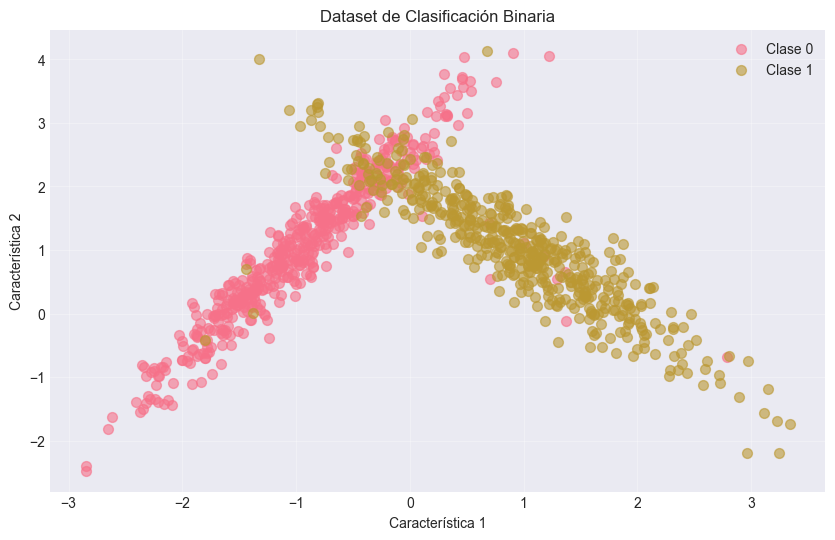

Tamaño entrenamiento: (800, 2)
Tamaño prueba: (200, 2)
Proporción clase 1 en entrenamiento: 0.50


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score
import seaborn as sns

# Configurar estilo de gráficos
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Generar datos sintéticos
X, y = make_classification(
    n_samples=1000,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    random_state=42,
    flip_y=0.05  # 5% de ruido
)

# Visualizar los datos
plt.figure(figsize=(10, 6))
plt.scatter(X[y==0, 0], X[y==0, 1], alpha=0.6, label='Clase 0', s=50)
plt.scatter(X[y==1, 0], X[y==1, 1], alpha=0.6, label='Clase 1', s=50)
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.title('Dataset de Clasificación Binaria')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalizar características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Tamaño entrenamiento: {X_train_scaled.shape}")
print(f"Tamaño prueba: {X_test_scaled.shape}")
print(f"Proporción clase 1 en entrenamiento: {y_train.mean():.2f}")

## 2. Implementación From Scratch

### 2.1 Función Sigmoide

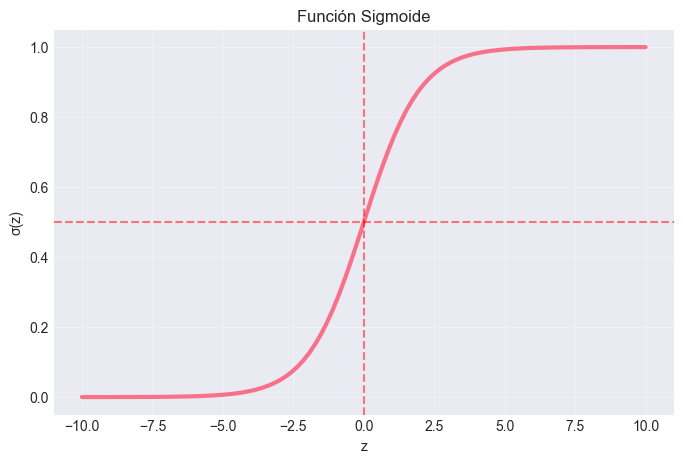

In [2]:
def sigmoid(z):
    """
    Función sigmoide (logística)
    z: valor o array de valores
    retorna: 1 / (1 + exp(-z))
    """
    # Evitar overflow numérico
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

# Verificar comportamiento
z_test = np.linspace(-10, 10, 100)
plt.figure(figsize=(8, 5))
plt.plot(z_test, sigmoid(z_test), linewidth=3)
plt.axhline(0.5, color='red', linestyle='--', alpha=0.5)
plt.axvline(0, color='red', linestyle='--', alpha=0.5)
plt.xlabel('z')
plt.ylabel('σ(z)')
plt.title('Función Sigmoide')
plt.grid(True, alpha=0.3)
plt.show()

### 2.2 Función de Costo (Entropía Cruzada Binaria)

In [3]:
def binary_cross_entropy(y_true, y_pred):
    """
    Calcula la entropía cruzada binaria (log loss)
    y_true: valores reales (0 o 1)
    y_pred: probabilidades predichas (entre 0 y 1)
    """
    # Evitar log(0)
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    
    # Costo por observación
    loss = - (y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    
    # Costo promedio
    return np.mean(loss)

# Ejemplo de verificación
y_true_example = np.array([1, 0, 1, 0])
y_pred_example = np.array([0.9, 0.1, 0.8, 0.2])
print(f"Entropía cruzada: {binary_cross_entropy(y_true_example, y_pred_example):.4f}")

Entropía cruzada: 0.1643


### 2.3 Clase LogisticRegressionScratch

In [4]:
class LogisticRegressionScratch:
    def __init__(self, learning_rate=0.01, n_iterations=1000, verbose=True):
        """
        Implementación desde cero de Regresión Logística
        learning_rate: tasa de aprendizaje para gradiente descendente
        n_iterations: número de iteraciones
        verbose: mostrar progreso
        """
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.verbose = verbose
        self.weights = None
        self.bias = None
        self.loss_history = []
        
    def _initialize_parameters(self, n_features):
        """Inicializar pesos y bias con valores pequeños"""
        self.weights = np.random.randn(n_features) * 0.01
        self.bias = 0
        
    def _compute_gradients(self, X, y, y_pred):
        """
        Calcular gradientes de la función de costo
        """
        n_samples = X.shape[0]
        
        # Gradiente para pesos
        dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
        
        # Gradiente para bias
        db = (1 / n_samples) * np.sum(y_pred - y)
        
        return dw, db
        
    def fit(self, X, y):
        """
        Entrenar el modelo usando gradiente descendente
        X: matriz de características (n_samples, n_features)
        y: vector de etiquetas (n_samples,)
        """
        # Inicializar parámetros
        n_samples, n_features = X.shape
        self._initialize_parameters(n_features)
        
        for i in range(self.n_iterations):
            # Forward pass: calcular predicciones
            z = np.dot(X, self.weights) + self.bias
            y_pred = sigmoid(z)
            
            # Calcular costo
            loss = binary_cross_entropy(y, y_pred)
            self.loss_history.append(loss)
            
            # Backward pass: calcular gradientes
            dw, db = self._compute_gradients(X, y, y_pred)
            
            # Actualizar parámetros
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
            
            # Mostrar progreso
            if self.verbose and (i % 100 == 0):
                print(f"Iteración {i:4d}, Costo: {loss:.6f}")
                
        return self
    
    def predict_proba(self, X):
        """
        Predecir probabilidades
        """
        z = np.dot(X, self.weights) + self.bias
        return sigmoid(z)
    
    def predict(self, X, threshold=0.5):
        """
        Predecir clases (0 o 1)
        """
        proba = self.predict_proba(X)
        return (proba >= threshold).astype(int)
    
    def score(self, X, y):
        """
        Calcular precisión (accuracy)
        """
        y_pred = self.predict(X)
        return np.mean(y_pred == y)

### 2.4 Entrenamiento del Modelo From Scratch

Iteración    0, Costo: 0.687140
Iteración  100, Costo: 0.344198
Iteración  200, Costo: 0.310816
Iteración  300, Costo: 0.300585
Iteración  400, Costo: 0.296290
Iteración  500, Costo: 0.294194
Iteración  600, Costo: 0.293075
Iteración  700, Costo: 0.292442
Iteración  800, Costo: 0.292068
Iteración  900, Costo: 0.291841


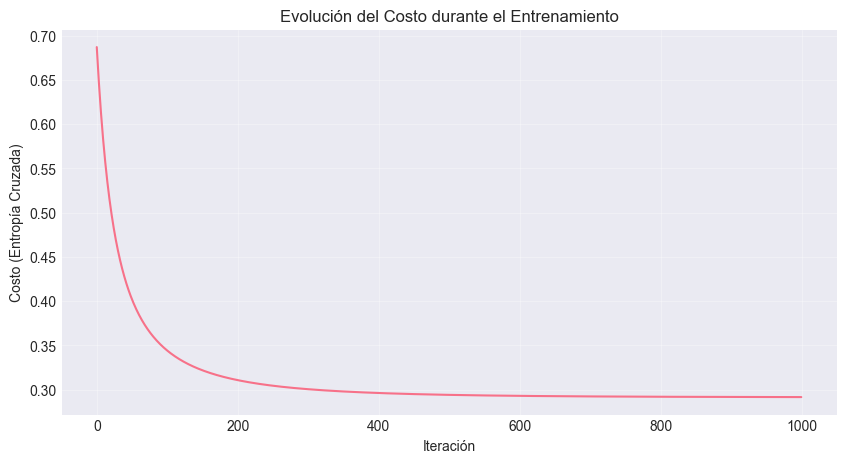


=== Modelo From Scratch ===
Precisión en entrenamiento: 0.8825
Precisión en prueba: 0.8900
Pesos: [ 3.23586402 -0.18627686]
Bias: 0.2247


In [5]:
# Crear y entrenar el modelo
model_scratch = LogisticRegressionScratch(
    learning_rate=0.1,
    n_iterations=1000,
    verbose=True
)

model_scratch.fit(X_train_scaled, y_train)

# Graficar evolución del costo
plt.figure(figsize=(10, 5))
plt.plot(model_scratch.loss_history)
plt.xlabel('Iteración')
plt.ylabel('Costo (Entropía Cruzada)')
plt.title('Evolución del Costo durante el Entrenamiento')
plt.grid(True, alpha=0.3)
plt.show()

# Predicciones en entrenamiento y prueba
y_train_pred_scratch = model_scratch.predict(X_train_scaled)
y_test_pred_scratch = model_scratch.predict(X_test_scaled)

# Métricas
train_acc = model_scratch.score(X_train_scaled, y_train)
test_acc = model_scratch.score(X_test_scaled, y_test)

print(f"\n=== Modelo From Scratch ===")
print(f"Precisión en entrenamiento: {train_acc:.4f}")
print(f"Precisión en prueba: {test_acc:.4f}")
print(f"Pesos: {model_scratch.weights}")
print(f"Bias: {model_scratch.bias:.4f}")

### 2.5 Visualización de la Frontera de Decisión

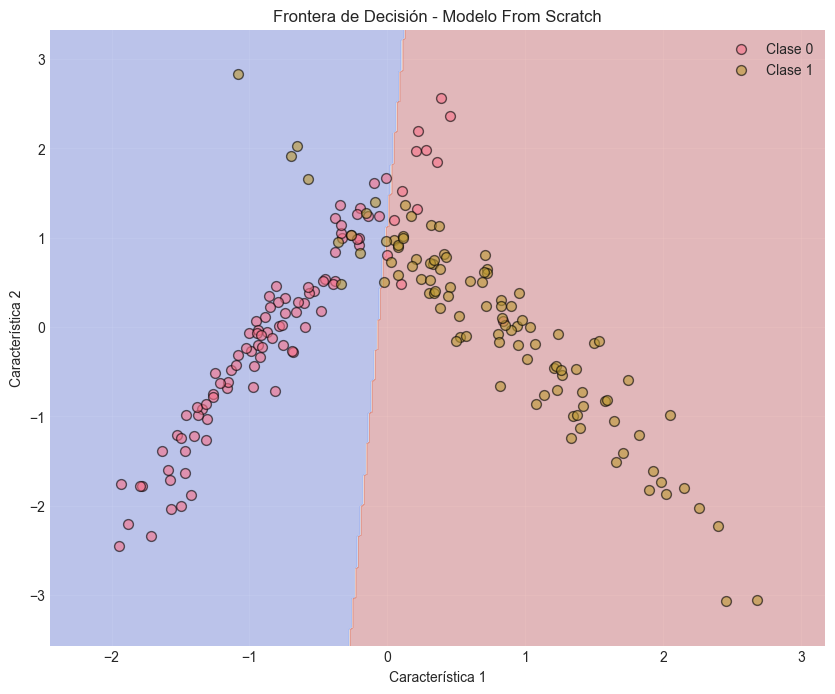

In [6]:
def plot_decision_boundary(X, y, model, title="Frontera de Decisión"):
    """
    Visualizar la frontera de decisión del modelo
    """
    # Crear malla de puntos
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    
    # Predecir para cada punto de la malla
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Graficar
    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X[y==0, 0], X[y==0, 1], alpha=0.6, label='Clase 0', s=50, edgecolors='k')
    plt.scatter(X[y==1, 0], X[y==1, 1], alpha=0.6, label='Clase 1', s=50, edgecolors='k')
    plt.xlabel('Característica 1')
    plt.ylabel('Característica 2')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Visualizar frontera de decisión (datos de prueba)
plot_decision_boundary(X_test_scaled, y_test, model_scratch, 
                       "Frontera de Decisión - Modelo From Scratch")

### 2.6 Matriz de Confusión

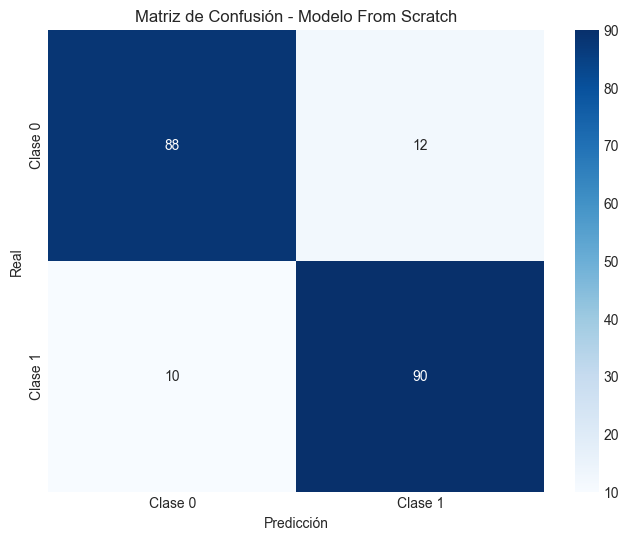


Reporte de Clasificación - Modelo From Scratch:
              precision    recall  f1-score   support

           0       0.90      0.88      0.89       100
           1       0.88      0.90      0.89       100

    accuracy                           0.89       200
   macro avg       0.89      0.89      0.89       200
weighted avg       0.89      0.89      0.89       200



In [7]:
def plot_confusion_matrix(y_true, y_pred, title="Matriz de Confusión"):
    """
    Visualizar matriz de confusión
    """
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Clase 0', 'Clase 1'],
                yticklabels=['Clase 0', 'Clase 1'])
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.title(title)
    plt.show()

plot_confusion_matrix(y_test, y_test_pred_scratch, 
                      "Matriz de Confusión - Modelo From Scratch")

# Reporte de clasificación
print("\nReporte de Clasificación - Modelo From Scratch:")
print(classification_report(y_test, y_test_pred_scratch))

## 3. Comparación con Scikit-Learn

In [8]:
# Modelo con Scikit-Learn
model_sklearn = LogisticRegression(
    C=1.0,           # Inverso de la regularización (1/λ)
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

model_sklearn.fit(X_train_scaled, y_train)

# Predicciones
y_train_pred_sklearn = model_sklearn.predict(X_train_scaled)
y_test_pred_sklearn = model_sklearn.predict(X_test_scaled)

# Métricas
train_acc_sklearn = model_sklearn.score(X_train_scaled, y_train)
test_acc_sklearn = model_sklearn.score(X_test_scaled, y_test)

print(f"\n=== Modelo Scikit-Learn ===")
print(f"Precisión en entrenamiento: {train_acc_sklearn:.4f}")
print(f"Precisión en prueba: {test_acc_sklearn:.4f}")
print(f"Pesos: {model_sklearn.coef_[0]}")
print(f"Bias: {model_sklearn.intercept_[0]:.4f}")

# Comparación de parámetros
print("\n=== Comparación de Coeficientes ===")
print(f"From Scratch - Pesos: {model_scratch.weights}")
print(f"Scikit-Learn - Pesos: {model_sklearn.coef_[0]}")
print(f"From Scratch - Bias: {model_scratch.bias:.4f}")
print(f"Scikit-Learn - Bias: {model_sklearn.intercept_[0]:.4f}")

# Comparación de precisión
print("\n=== Comparación de Precisión ===")
print(f"From Scratch - Test Accuracy: {test_acc:.4f}")
print(f"Scikit-Learn - Test Accuracy: {test_acc_sklearn:.4f}")
print(f"Diferencia: {abs(test_acc - test_acc_sklearn):.4f}")


=== Modelo Scikit-Learn ===
Precisión en entrenamiento: 0.8838
Precisión en prueba: 0.8900
Pesos: [ 3.20909819 -0.20820543]
Bias: 0.2493

=== Comparación de Coeficientes ===
From Scratch - Pesos: [ 3.23586402 -0.18627686]
Scikit-Learn - Pesos: [ 3.20909819 -0.20820543]
From Scratch - Bias: 0.2247
Scikit-Learn - Bias: 0.2493

=== Comparación de Precisión ===
From Scratch - Test Accuracy: 0.8900
Scikit-Learn - Test Accuracy: 0.8900
Diferencia: 0.0000


### 3.1 Visualización Comparativa

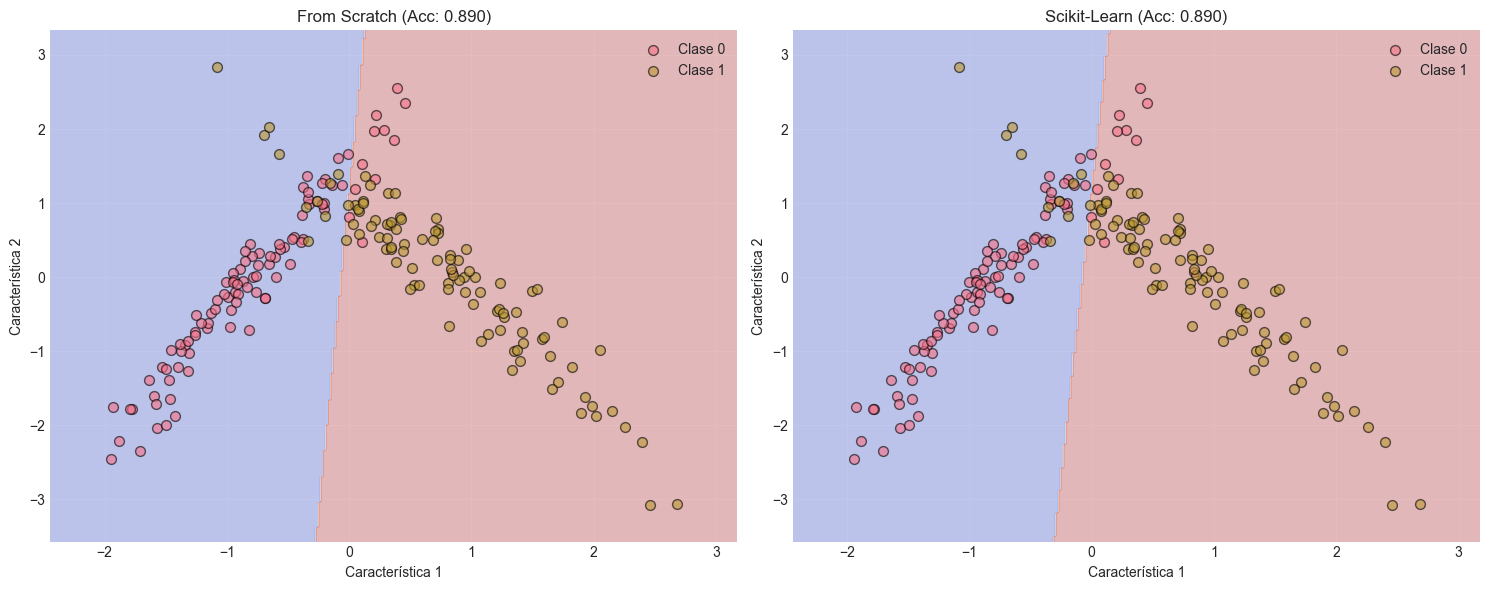

In [9]:
# Crear malla para visualización
x_min, x_max = X_test_scaled[:, 0].min() - 0.5, X_test_scaled[:, 0].max() + 0.5
y_min, y_max = X_test_scaled[:, 1].min() - 0.5, X_test_scaled[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Visualizar ambas fronteras de decisión
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Modelo From Scratch
Z_scratch = model_scratch.predict(np.c_[xx.ravel(), yy.ravel()])
Z_scratch = Z_scratch.reshape(xx.shape)

axes[0].contourf(xx, yy, Z_scratch, alpha=0.3, cmap='coolwarm')
axes[0].scatter(X_test_scaled[y_test==0, 0], X_test_scaled[y_test==0, 1], 
                alpha=0.6, label='Clase 0', s=50, edgecolors='k')
axes[0].scatter(X_test_scaled[y_test==1, 0], X_test_scaled[y_test==1, 1], 
                alpha=0.6, label='Clase 1', s=50, edgecolors='k')
axes[0].set_xlabel('Característica 1')
axes[0].set_ylabel('Característica 2')
axes[0].set_title(f'From Scratch (Acc: {test_acc:.3f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Modelo Scikit-Learn
Z_sklearn = model_sklearn.predict(np.c_[xx.ravel(), yy.ravel()])
Z_sklearn = Z_sklearn.reshape(xx.shape)

axes[1].contourf(xx, yy, Z_sklearn, alpha=0.3, cmap='coolwarm')
axes[1].scatter(X_test_scaled[y_test==0, 0], X_test_scaled[y_test==0, 1], 
                alpha=0.6, label='Clase 0', s=50, edgecolors='k')
axes[1].scatter(X_test_scaled[y_test==1, 0], X_test_scaled[y_test==1, 1], 
                alpha=0.6, label='Clase 1', s=50, edgecolors='k')
axes[1].set_xlabel('Característica 1')
axes[1].set_ylabel('Característica 2')
axes[1].set_title(f'Scikit-Learn (Acc: {test_acc_sklearn:.3f})')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Interpretación de Coeficientes (Odds Ratios)


=== Interpretación de Coeficientes (Odds Ratios) ===

Modelo From Scratch:
Característica 1: Coef = 3.2359, Odds Ratio = 25.4283
  → Un incremento de 1 unidad en X1 multiplica las odds por 25.4283
Característica 2: Coef = -0.1863, Odds Ratio = 0.8300
  → Un incremento de 1 unidad en X2 multiplica las odds por 0.8300

Modelo Scikit-Learn:
Característica 1: Coef = 3.2091, Odds Ratio = 24.7568
  → Un incremento de 1 unidad en X1 multiplica las odds por 24.7568
Característica 2: Coef = -0.2082, Odds Ratio = 0.8120
  → Un incremento de 1 unidad en X2 multiplica las odds por 0.8120


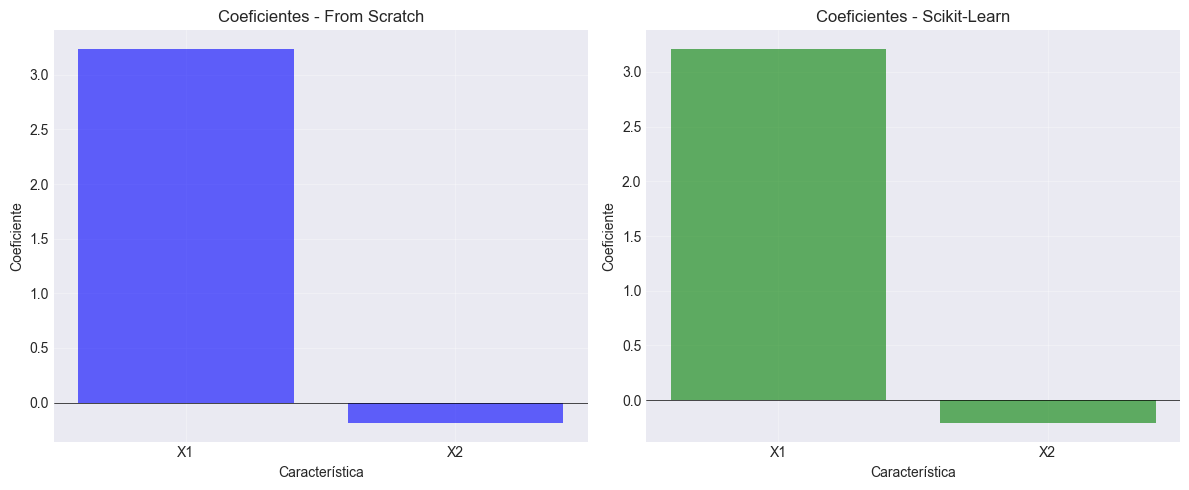

In [10]:
# Calcular odds ratios
odds_ratio_scratch = np.exp(model_scratch.weights)
odds_ratio_sklearn = np.exp(model_sklearn.coef_[0])

print("\n=== Interpretación de Coeficientes (Odds Ratios) ===")
print("\nModelo From Scratch:")
for i, (coef, odds) in enumerate(zip(model_scratch.weights, odds_ratio_scratch)):
    print(f"Característica {i+1}: Coef = {coef:.4f}, Odds Ratio = {odds:.4f}")
    print(f"  → Un incremento de 1 unidad en X{i+1} multiplica las odds por {odds:.4f}")

print("\nModelo Scikit-Learn:")
for i, (coef, odds) in enumerate(zip(model_sklearn.coef_[0], odds_ratio_sklearn)):
    print(f"Característica {i+1}: Coef = {coef:.4f}, Odds Ratio = {odds:.4f}")
    print(f"  → Un incremento de 1 unidad en X{i+1} multiplica las odds por {odds:.4f}")

# Visualizar coeficientes
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(['X1', 'X2'], model_scratch.weights, color='blue', alpha=0.6)
plt.axhline(0, color='black', linestyle='-', linewidth=0.5)
plt.xlabel('Característica')
plt.ylabel('Coeficiente')
plt.title('Coeficientes - From Scratch')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.bar(['X1', 'X2'], model_sklearn.coef_[0], color='green', alpha=0.6)
plt.axhline(0, color='black', linestyle='-', linewidth=0.5)
plt.xlabel('Característica')
plt.ylabel('Coeficiente')
plt.title('Coeficientes - Scikit-Learn')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Análisis de Probabilidades

In [11]:
# Obtener probabilidades para algunos ejemplos de prueba
n_examples = 5
indices = np.random.choice(len(X_test_scaled), n_examples, replace=False)

print("\n=== Análisis de Predicciones ===")
print("Muestra de predicciones con probabilidades:\n")

for idx in indices:
    X_sample = X_test_scaled[idx:idx+1]
    y_real = y_test[idx]
    
    # Predicciones de ambos modelos
    prob_scratch = model_scratch.predict_proba(X_sample)[0]
    prob_sklearn = model_sklearn.predict_proba(X_sample)[0][1]
    pred_scratch = model_scratch.predict(X_sample)[0]
    pred_sklearn = model_sklearn.predict(X_sample)[0]
    
    print(f"Ejemplo {idx}:")
    print(f"  Valor real: {y_real}")
    print(f"  From Scratch - Probabilidad: {prob_scratch:.4f}, Predicción: {pred_scratch}")
    print(f"  Scikit-Learn - Probabilidad: {prob_sklearn:.4f}, Predicción: {pred_sklearn}")
    print()


=== Análisis de Predicciones ===
Muestra de predicciones con probabilidades:

Ejemplo 162:
  Valor real: 1
  From Scratch - Probabilidad: 0.3615, Predicción: 0
  Scikit-Learn - Probabilidad: 0.3642, Predicción: 0

Ejemplo 64:
  Valor real: 0
  From Scratch - Probabilidad: 0.0468, Predicción: 0
  Scikit-Learn - Probabilidad: 0.0492, Predicción: 0

Ejemplo 44:
  Valor real: 0
  From Scratch - Probabilidad: 0.2249, Predicción: 0
  Scikit-Learn - Probabilidad: 0.2263, Predicción: 0

Ejemplo 135:
  Valor real: 0
  From Scratch - Probabilidad: 0.3357, Predicción: 0
  Scikit-Learn - Probabilidad: 0.3377, Predicción: 0

Ejemplo 10:
  Valor real: 1
  From Scratch - Probabilidad: 0.5521, Predicción: 1
  Scikit-Learn - Probabilidad: 0.5525, Predicción: 1



## 6. Curva ROC y AUC

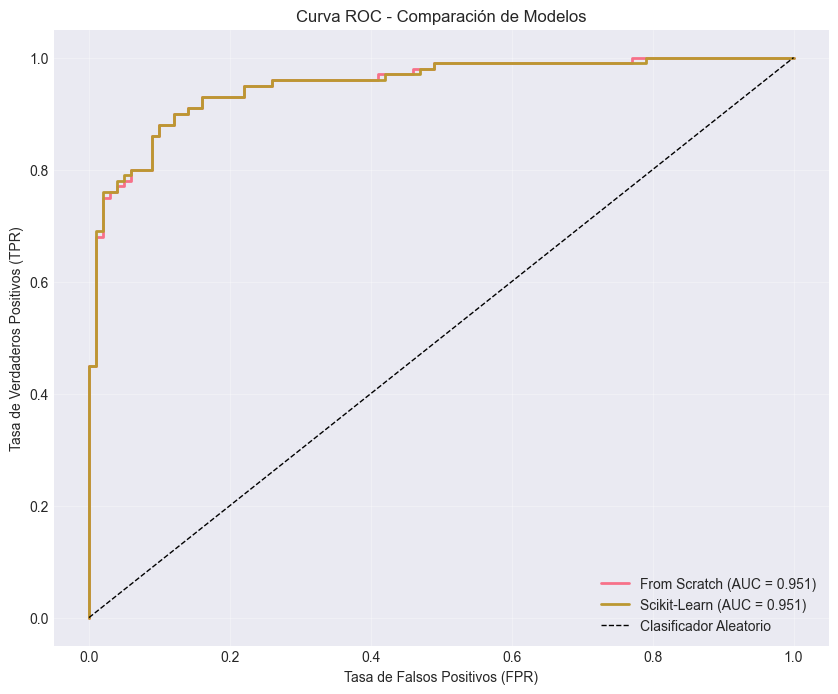


AUC - From Scratch: 0.9512
AUC - Scikit-Learn: 0.9512


In [12]:
# Calcular probabilidades para ambos modelos
probs_scratch = model_scratch.predict_proba(X_test_scaled)
probs_sklearn = model_sklearn.predict_proba(X_test_scaled)[:, 1]

# Calcular ROC
fpr_scratch, tpr_scratch, _ = roc_curve(y_test, probs_scratch)
fpr_sklearn, tpr_sklearn, _ = roc_curve(y_test, probs_sklearn)

auc_scratch = roc_auc_score(y_test, probs_scratch)
auc_sklearn = roc_auc_score(y_test, probs_sklearn)

# Graficar ROC
plt.figure(figsize=(10, 8))
plt.plot(fpr_scratch, tpr_scratch, label=f'From Scratch (AUC = {auc_scratch:.3f})', linewidth=2)
plt.plot(fpr_sklearn, tpr_sklearn, label=f'Scikit-Learn (AUC = {auc_sklearn:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Clasificador Aleatorio', linewidth=1)
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - Comparación de Modelos')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nAUC - From Scratch: {auc_scratch:.4f}")
print(f"AUC - Scikit-Learn: {auc_sklearn:.4f}")

## 7. Experimentos con Hiperparámetros

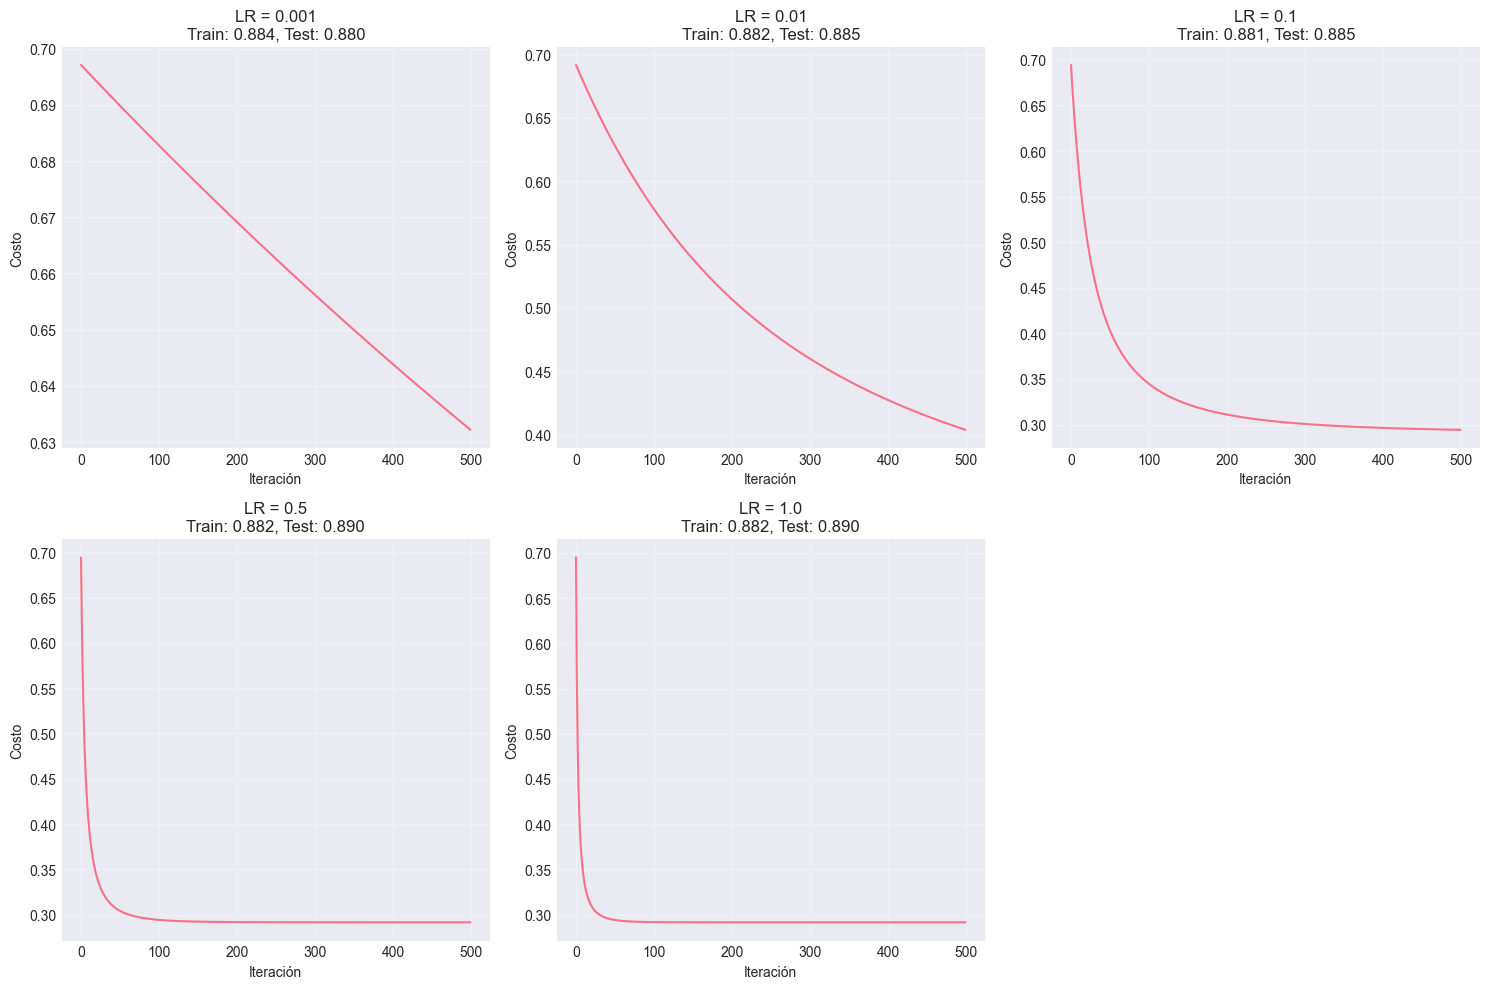


=== Resumen de Hiperparámetros ===
Tasa Aprendizaje | Train Acc | Test Acc
---------------------------------------------
         0.001 | 0.8838   | 0.8800
         0.010 | 0.8825   | 0.8850
         0.100 | 0.8812   | 0.8850
         0.500 | 0.8825   | 0.8900
         1.000 | 0.8825   | 0.8900


In [13]:
# Probar diferentes tasas de aprendizaje
learning_rates = [0.001, 0.01, 0.1, 0.5, 1.0]
results = []

plt.figure(figsize=(15, 10))

for i, lr in enumerate(learning_rates):
    model = LogisticRegressionScratch(learning_rate=lr, n_iterations=500, verbose=False)
    model.fit(X_train_scaled, y_train)
    train_acc = model.score(X_train_scaled, y_train)
    test_acc = model.score(X_test_scaled, y_test)
    results.append((lr, train_acc, test_acc, model.loss_history))
    
    plt.subplot(2, 3, i+1)
    plt.plot(model.loss_history)
    plt.title(f'LR = {lr}\nTrain: {train_acc:.3f}, Test: {test_acc:.3f}')
    plt.xlabel('Iteración')
    plt.ylabel('Costo')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Mostrar resumen
print("\n=== Resumen de Hiperparámetros ===")
print("Tasa Aprendizaje | Train Acc | Test Acc")
print("-" * 45)
for lr, train_acc, test_acc, _ in results:
    print(f"{lr:14.3f} | {train_acc:.4f}   | {test_acc:.4f}")

## Ejercicios Propuestos

1. **Regularización L2**: Añadir término de regularización al costo: `J + λ * ||w||²`. Actualizar los gradientes.

2. **Mini-batch Gradient Descent**: Modificar el entrenamiento para usar mini-batches en lugar de batch completo.

3. **Características Polinómicas**: Agregar características polinómicas y ver cómo cambia la frontera de decisión.

4. **Umbral Óptimo**: Encontrar el umbral que maximiza el F1-score.

5. **Interpretación Avanzada**: Calcular intervalos de confianza para los coeficientes usando bootstrapping.
